In [1]:
import pandas as pd
import sqlite3
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Load CSV
df = pd.read_csv('cookie_cats.csv')

# Preview
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (90189, 5)

First 5 rows:
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True

Data types:
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Missing values:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


In [2]:
# Load into SQLite
conn = sqlite3.connect('cookie_cats.db')
df.to_sql('players', conn, if_exists='replace', index=False)

# Basic group summary using SQL
query = """
    SELECT 
        version,
        COUNT(userid) as total_players,
        SUM(CASE WHEN retention_1 = 1 THEN 1 ELSE 0 END) as retained_day1,
        SUM(CASE WHEN retention_7 = 1 THEN 1 ELSE 0 END) as retained_day7,
        ROUND(AVG(CASE WHEN retention_1 = 1 THEN 1.0 ELSE 0 END) * 100, 2) as retention_1_pct,
        ROUND(AVG(CASE WHEN retention_7 = 1 THEN 1.0 ELSE 0 END) * 100, 2) as retention_7_pct,
        ROUND(AVG(sum_gamerounds), 2) as avg_rounds
    FROM players
    GROUP BY version
"""

summary = pd.read_sql_query(query, conn)
print(summary.to_string())

   version  total_players  retained_day1  retained_day7  retention_1_pct  retention_7_pct  avg_rounds
0  gate_30          44700          20034           8502            44.82            19.02       52.46
1  gate_40          45489          20119           8279            44.23            18.20       51.30


In [3]:
# Pull the two groups from SQLite
gate_30 = pd.read_sql_query("SELECT retention_7 FROM players WHERE version = 'gate_30'", conn)
gate_40 = pd.read_sql_query("SELECT retention_7 FROM players WHERE version = 'gate_40'", conn)

# Convert to 1s and 0s
r30 = gate_30['retention_7'].astype(int)
r40 = gate_40['retention_7'].astype(int)

# Count retained players
n30 = len(r30)
n40 = len(r40)
retained_30 = r30.sum()
retained_40 = r40.sum()

print(f"gate_30: {retained_30}/{n30} retained ({retained_30/n30*100:.2f}%)")
print(f"gate_40: {retained_40}/{n40} retained ({retained_40/n40*100:.2f}%)")

# Two-proportion z-test
counts = [retained_30, retained_40]
nobs = [n30, n40]

stat, pvalue = proportions_ztest(counts, nobs, alternative='larger')

print(f"\nZ-statistic: {stat:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("\n✓ Result is statistically significant (p < 0.05)")
    print("We reject the null hypothesis — gate_30 has genuinely higher 7-day retention")
else:
    print("\n✗ Result is NOT statistically significant (p >= 0.05)")
    print("We cannot conclude gate_30 is better")

gate_30: 8502/44700 retained (19.02%)
gate_40: 8279/45489 retained (18.20%)

Z-statistic: 3.1644
P-value: 0.0008

✓ Result is statistically significant (p < 0.05)
We reject the null hypothesis — gate_30 has genuinely higher 7-day retention


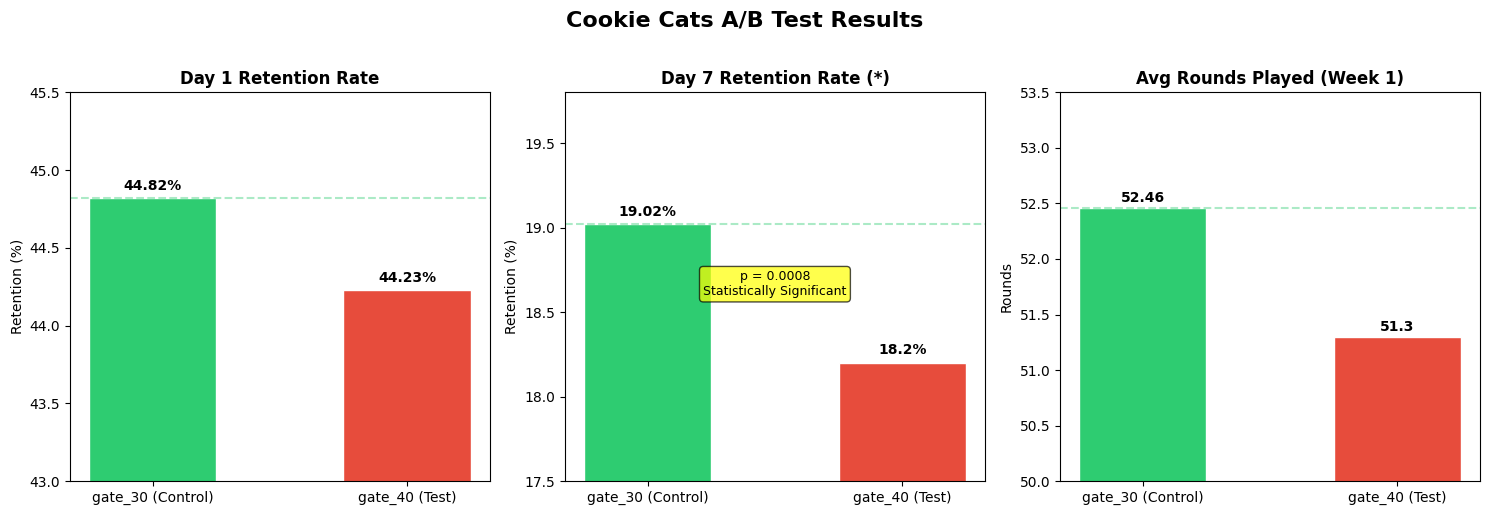

Chart saved to outputs/ab_test_results.png


In [5]:
import os
os.makedirs('outputs', exist_ok=True)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Data ----
versions = ['gate_30 (Control)', 'gate_40 (Test)']
ret1 = [44.82, 44.23]
ret7 = [19.02, 18.20]
avg_rounds = [52.46, 51.30]
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cookie Cats A/B Test Results', fontsize=16, fontweight='bold', y=1.02)

# ---- Chart 1: Day 1 Retention ----
bars1 = axes[0].bar(versions, ret1, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Day 1 Retention Rate', fontweight='bold')
axes[0].set_ylabel('Retention (%)')
axes[0].set_ylim(43, 45.5)
axes[0].axhline(y=ret1[0], color='#2ecc71', linestyle='--', alpha=0.4)
for bar, val in zip(bars1, ret1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val}%', ha='center', fontweight='bold')

# ---- Chart 2: Day 7 Retention ----
bars2 = axes[1].bar(versions, ret7, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('Day 7 Retention Rate (*)', fontweight='bold')
axes[1].set_ylabel('Retention (%)')
axes[1].set_ylim(17.5, 19.8)
axes[1].axhline(y=ret7[0], color='#2ecc71', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, ret7):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val}%', ha='center', fontweight='bold')

# ---- Chart 3: Avg Rounds Played ----
bars3 = axes[2].bar(versions, avg_rounds, color=colors, width=0.5, edgecolor='white')
axes[2].set_title('Avg Rounds Played (Week 1)', fontweight='bold')
axes[2].set_ylabel('Rounds')
axes[2].set_ylim(50, 53.5)
axes[2].axhline(y=avg_rounds[0], color='#2ecc71', linestyle='--', alpha=0.4)
for bar, val in zip(bars3, avg_rounds):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val}', ha='center', fontweight='bold')

# ---- Annotation on Chart 2 ----
axes[1].annotate('p = 0.0008\nStatistically Significant',
                xy=(0.5, 18.6), xycoords='data',
                fontsize=9, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('outputs/ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/ab_test_results.png")

In [9]:
# ---- Business Impact Calculation ----

# Baseline numbers
total_daily_installs = 90189  # from our sample (1 week period)
weekly_installs = total_daily_installs
gate_30_ret7 = 0.1902
gate_40_ret7 = 0.1820

# Retention difference
ret_diff = gate_30_ret7 - gate_40_ret7
print(f"7-day retention difference: {ret_diff*100:.2f} percentage points")

# How many extra players retained per week with gate_30
extra_retained = weekly_installs * ret_diff
print(f"Extra players retained per week (gate_30 vs gate_40): {extra_retained:.0f} players")

# Annualised
annual_extra = extra_retained * 52
print(f"Annualised extra retained players: {annual_extra:,.0f} players")

# Revenue impact
# Assumption: industry average mobile game ARPU (Average Revenue Per User) = $0.05/day
# Source: mobile gaming industry benchmark
arpu_per_day = 0.05
days_retained = 7
revenue_per_retained_user = arpu_per_day * days_retained

annual_revenue_impact = annual_extra * revenue_per_retained_user
print(f"Assumed ARPU: ${arpu_per_day}/day over {days_retained} days = ${revenue_per_retained_user:.2f}/user")
print(f"Estimated annual revenue impact of keeping gate_30: ${annual_revenue_impact:,.0f}")
print("\n--- Recommendation ---")
print("Keep the gate at level 30.")
print("Moving it to level 40 costs ~740 retained players per week.")
print(f"At industry ARPU benchmarks, this represents ~${annual_revenue_impact:,.0f} in annual revenue risk.")
print("The data strongly supports maintaining the current gate position.")

7-day retention difference: 0.82 percentage points
Extra players retained per week (gate_30 vs gate_40): 740 players
Annualised extra retained players: 38,457 players
Assumed ARPU: $0.05/day over 7 days = $0.35/user
Estimated annual revenue impact of keeping gate_30: $13,460

--- Recommendation ---
Keep the gate at level 30.
Moving it to level 40 costs ~740 retained players per week.
At industry ARPU benchmarks, this represents ~$13,460 in annual revenue risk.
The data strongly supports maintaining the current gate position.


In [10]:
import pandas as pd

# ---- Final Summary Table ----
summary_data = {
    'Metric': [
        'Total Players',
        'Day 1 Retention',
        'Day 7 Retention',
        'Avg Rounds Played (Week 1)',
        'Z-Statistic (Day 7)',
        'P-Value (Day 7)',
        'Statistically Significant?',
        'Extra Players Retained/Week',
        'Est. Annual Revenue at Risk'
    ],
    'gate_30 (Control)': [
        '44,700',
        '44.82%',
        '19.02%',
        '52.46',
        '3.16',
        '0.0008',
        '✓ Yes (p < 0.05)',
        '-',
        '-'
    ],
    'gate_40 (Test)': [
        '45,489',
        '44.23%',
        '18.20%',
        '51.30',
        '-',
        '-',
        '-',
        '-',
        '-'
    ],
    'Difference': [
        '-',
        '-0.59%',
        '-0.82%',
        '-1.16',
        '-',
        '-',
        '-',
        '~740 players',
        '~$13,460'
    ]
}

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))

# Save as CSV for reference
summary_table.to_csv('outputs/summary_table.csv', index=False)
print("\nSummary table saved to outputs/summary_table.csv")

                     Metric gate_30 (Control) gate_40 (Test)   Difference
              Total Players            44,700         45,489            -
            Day 1 Retention            44.82%         44.23%       -0.59%
            Day 7 Retention            19.02%         18.20%       -0.82%
 Avg Rounds Played (Week 1)             52.46          51.30        -1.16
        Z-Statistic (Day 7)              3.16              -            -
            P-Value (Day 7)            0.0008              -            -
 Statistically Significant?  ✓ Yes (p < 0.05)              -            -
Extra Players Retained/Week                 -              - ~740 players
Est. Annual Revenue at Risk                 -              -     ~$13,460

Summary table saved to outputs/summary_table.csv
